# Trabajo Semanal 2 - Filtro Pasa Bajos Butterworth de orden 6
*Alumno: Contreras Juan Manuel*  
*Materia: Teoría de Circuitos II*  
*Institución: UTN FRBA*  

---

## 1. Obtención de la Función Transferencia $T(s)$

Para una aproximación Butterworth con $\epsilon^2 = 1$ (atenuación de $3 \text{ dB}$), la magnitud al cuadrado de la transferencia es:

$$|T(j\omega)|^2 = \frac{1}{1 + \omega^{2n}} \xrightarrow{n=6} \frac{1}{1 + \omega^{12}}$$

### Localización de Polos
Sustituyendo $s = j\omega \implies \omega^2 = -s^2$, buscamos las raíces de:

$$1 + (-s^2)^6 = 1 + s^{12} = 0 \implies s = \sqrt[12]{-1}$$

Los 12 polos se distribuyen cada $30^\circ$ ($\pi/6$) en una circunferencia unitaria. Para que el sistema sea estable, elegimos los 6 polos del semiplano izquierdo.

$$(T(s))^2=T(s) \cdot T(-s)$$

Los ángulos de los polos respecto al eje real negativo son:
* $\theta_1 = \pm 15^\circ = \pm \pi/12$
* $\theta_2 = \pm 45^\circ = \pm \pi/4$
* $\theta_3 = \pm 75^\circ = \pm 5\pi/12$

### Expresión Factorizada en SOS
Cada par de polos complejos conjugados conforma una sección de segundo orden:
$$T(s) = \prod_{i=1}^{3} \frac{1}{s^2 + \frac{\omega_0}{Q_i}s + \omega_0^2}$$

Donde, para Butterworth, $\omega_0 = 1$ y $Q_i = \frac{1}{2 \cos(\theta_i)}$. Calculamos los valores:
1. **$Q_1$ (para $15^\circ$):** $1 / (2 \cos(15^\circ)) \approx 0,517$
2. **$Q_2$ (para $45^\circ$):** $1 / (2 \cos(45^\circ)) \approx 0,707$
3. **$Q_3$ (para $75^\circ$):** $1 / (2 \cos(75^\circ)) \approx 1,931$
---

## 2. Análisis Cualitativo de la Respuesta

### Diagrama de Polos y Ceros (Plano $s$)
* **Ubicación de Polos:** Los 6 polos de la transferencia $T(s)$ se distribuyen uniformemente sobre una **semicircunferencia unitaria** en el semiplano izquierdo.
* **Distribución Angular:** Presentan una separación de $30^\circ$ entre sí. Dado que $n$ es par, no existen polos sobre el eje real. Los ángulos respecto al eje real negativo son $\pm 15^\circ, \pm 45^\circ, \text{ y } \pm 75^\circ$.
* **Ceros:** Es un filtro **todo polo**, por lo tanto, no posee ceros.

### Respuesta de Módulo $|T(j\omega)|$
* **Máxima Planicidad:** En la banda de paso ($\omega < 1$), la respuesta es plana.
* **Frecuencia de Corte:** En la frecuencia de corte normalizada $\omega = 1$, la magnitud es de $1/\sqrt{2}$, lo que equivale a una caída de $-3 \text{ dB}$.
* **Banda de Transición:** Al ser de orden $6$, la caída en la banda de parada es de $-120 \text{ dB/década}$, por lo que tiene una selectividad elevada.

### Respuesta de Fase $\phi(\omega)$
* **Comportamiento:** La fase es una función decreciente, indicando un atraso de señal, el decrecimiento comienza en $\frac{\omega_0}{10}$ hasta $10 \cdot \omega_0$ con una pentiende de $-270 \text{ °/década}$.
* **Fase en el corte:** En $\omega = 1$, la fase es de $-n \cdot 45^\circ = -270^\circ$.
* **Fase Asintótica:** Para frecuencias muy elevadas ($\omega \to \infty$), la fase tiende a un valor final de $-n \cdot 90^\circ = -540^\circ$.

---

## 3. Cácluclo individual de las Redes Normalizadas

La $T(s)$ se va a componer de 3 redes individuales, procedemos a calcular las transferencias y normalizar en función de los parametros del filtro.

La distribución se realiza en orden creciente de $Q$:

### SOS 1: Sallen-Key (Low-Pass)
Para obtener la función de transferencia $T(s) = \frac{V_2}{V_1}$, analizamos el circuito considerando una ganancia de banda de paso $K$.

#### 1. Definición de Parámetros
<img src="./img/circuito_01.jpg" width="500">  

* $V_a$: Nodo de unión entre $R_1$, $R_2$ y $C_1$.
* $V_b$: Nodo en la entrada no inversora ($+$).
* $V_2$: Nodo de salida. Debido a la realimentación negativa: $V_2 = V_b \cdot \left( 1 + \frac{R_4}{R_3} \right) = V_b \cdot K$.
* Por lo tanto, **$V_b = \frac{V_2}{K}$**.

#### 2. Ecuaciones de Nodo
En el nodo $V_b$:
$$\frac{V_a - V_b}{R_2} = V_b \cdot sC_2 \implies V_a = V_b(1 + sR_2C_2)$$
Sustituyendo $V_b$ en función de $V_2$:
$$V_a = \frac{V_2}{K}(1 + sR_2C_2) \quad \text{--- (Ec. 1)}$$

En el nodo $V_a$:
$$\frac{V_1 - V_a}{R_1} = \frac{V_a - V_b}{R_2} + (V_a - V_2)sC_1$$
Multiplicando por $R_1$:
$$V_1 = V_a \left(1 + \frac{R_1}{R_2} + sR_1C_1\right) - V_b \frac{R_1}{R_2} - V_2 sR_1C_1 \quad \text{--- (Ec. 2)}$$

#### 3. Obtención de la Función de Transferencia Genérica
Sustituimos la **(Ec. 1)** y la relación $V_b = V_2/K$ en la **(Ec. 2)**:
$$V_1 = \frac{V_2}{K}(1 + sR_2C_2) \left(1 + \frac{R_1}{R_2} + sR_1C_1\right) - \frac{V_2}{K} \frac{R_1}{R_2} - V_2 sR_1C_1$$

Operando y agrupando términos en $s$ para llegar a la forma mónica:
$$T(s) = \frac{V_2}{V_1} = \frac{\frac{K}{R_1 R_2 C_1 C_2}}{s^2 + s \left( \frac{1}{R_1 C_1} + \frac{1}{R_2 C_1} + \frac{1 - K}{R_2 C_2} \right) + \frac{1}{R_1 R_2 C_1 C_2}}$$

#### 4. Normalización
Si adoptamos $\Omega_z = R_1$ y $\Omega_\omega = \omega_0$:
* Definimos $R_1=R_2=R_4$
* Los capacitores quedan en función de $Q$ y de $K$: $C_1=\frac{Q^{-1}+\sqrt{Q^{-2}-8(1-K)}}{4}$ , $C_2=\frac{4}{Q^{-1}+\sqrt{Q^{-2}-8(1-K)}}$.
* La resistencia $R_3$ depende de la ganancia $K$: $R_3=\frac{1}{K-1}$.

<img src="./img/circuito_02.jpg" width="500">  

---

### SOS 2: KHN (Variable de Estado)

#### 1. Definición de Nodos y Ecuaciones
<img src="./img/circuito_03.jpg" width="500">  

Basándonos en el análisis de corrientes en los nodos principales:

* Nodo $V_a$ (Entrada No Inversora OA1):
    $$V_a(G_1 + G_2 + G_3) - V_i G_1 - V_o G_2 - V_b G_3 = 0\quad \text{--- (Ec. 1)}$$
* Integrador 1 ($V_c$ en función de $V_b$):
    $$-V_b G_4 - V_c Y_{C1} = 0 \implies V_b = -V_c \frac{Y_{C1}}{G_4}$$
* Integrador 2 ($V_o$ en función de $V_c$):
    $$-V_c G_5 - V_o Y_{C2} = 0 \implies V_c = -V_o \frac{Y_{C2}}{G_5}$$
* Relación de realimentación ($V_a$):
    $$V_a(G_6 + G_7) - V_c G_6 = 0 \implies V_a = V_c \frac{G_6}{G_6 + G_7}$$

#### 2. Obtención de la Función de Transferencia Genérica
Despejando las variables anteriores, expresamos todas las tensiones intermedias en función de la salida $V_o$:
* $V_c = -V_o \frac{sC_2}{G_5}$
* $V_b = V_o \frac{s^2 C_1 C_2}{G_4 G_5}$
* $V_a = -V_o \frac{s C_2 G_6}{G_5(G_6 + G_7)}$

Para hallar $T(s)$, sustituimos las expresiones de $V_a$ y $V_b$ (en función de $V_o$) en $\text{(Ec. 1)}$:

$$\left[ -V_o \frac{s C_2 G_6}{G_5(G_6 + G_7)} \right] (G_1 + G_2 + G_3) - V_i G_1 - V_o G_2 - \left[ V_o \frac{s^2 C_1 C_2}{G_4 G_5} \right] G_3 = 0$$

Reordenamos los términos para agrupar todo lo que multiplica a $V_o$ y aislamos $V_i$:

$$-V_i G_1 = V_o \left[ s^2 \frac{C_1 C_2 G_3}{G_4 G_5} + s \frac{C_2 G_6 (G_1 + G_2 + G_3)}{G_5(G_6 + G_7)} + G_2 \right]$$

Multiplicamos toda la ecuación por $\frac{G_4 G_5}{C_1 C_2 G_3}$ para que el término $s^2$ quede con coeficiente unitario (**forma mónica**):

$$\frac{V_o}{V_i} = \frac{- \frac{G_1 G_4 G_5}{C_1 C_2 G_3}}{s^2 + s \frac{G_4 G_6 (G_1 + G_2 + G_3)}{C_1 G_3 (G_6 + G_7)} + \frac{G_2 G_4 G_5}{C_1 C_2 G_3}}$$

#### 3. Función de Transferencia Final
Expresando las conductancias en términos de resistencias ($G_i = 1/R_i$):

$$T(s) = \frac{-\frac{R_3}{C_1 C_2 R_1 R_4 R_5}}{s^2 + s \frac{R_3}{C_1 R_6 R_4} \frac{(\frac{1}{R_1} + \frac{1}{R_2} + \frac{1}{R_3})}{(\frac{1}{R_6} + \frac{1}{R_7})} + \frac{R_3}{C_1 C_2 R_2 R_4 R_5}}$$

#### 4. Normalización
Si adoptamos $\Omega_z = R_1$ y $\Omega_\omega = \omega_0$:
* Definimos $R_1=R_2=R_3=R_4=R_5=R_6=R_7$
* Los capacitores quedan en función de $Q$: $C_1=\frac{3Q}{2}$ , $C_2=\frac{2}{3Q}$.

<img src="./img/circuito_04.jpg" width="500">  

---

### SOS 3: MFB (Realimentación Múltiple)

#### 1. Definición de Nodos y Ecuaciones
<img src="./img/circuito_05.jpg" width="500">  

* Nodo $V_b$ (Entrada Inversora):
    Como la entrada no inversora está a tierra, $V_b = 0$. La suma de corrientes que llegan al nodo a través de $R_2$ y $C_2$ es:
    $$-V_a G_2 - V_o Y_{C2} = 0 \implies V_a = - \frac{V_o Y_{C2}}{G_2} \quad \text{--- (Ec. 1)}$$

* Nodo $V_a$ (Nodo Central):
    $$V_a(G_1 + G_2 + G_3 + Y_{C1}) - V_o G_1 - V_i G_3 = 0 \quad \text{--- (Ec. 2)}$$

#### 2. Obtención de la Función de Transferencia Genérica
Sustituimos la **(Ec. 1)** en la **(Ec. 2)** para eliminar $V_a$:
$$-V_o \left( \frac{Y_{C2} (G_1 + G_2 + G_3) + Y_{C2} Y_{C1} + G_1 G_2}{G_2} \right) = V_i G_3$$

Operando y agrupando términos para llegar a la **forma mónica**:
$$T(s) = \frac{V_o}{V_i} = \frac{- \frac{G_3 G_2}{C_1 C_2}}{s^2 + s \frac{G_1 + G_2 + G_3}{C_1} + \frac{G_1 G_2}{C_1 C_2}}$$

#### 3. Función de Transferencia Final
Expresando las conductancias en términos de resistencias ($R_i = 1/G_i$):
$$T(s) = \frac{-\frac{1}{R_2 R_3 C_1 C_2}}{s^2 + s \frac{1}{C_1} \left( \frac{1}{R_1} + \frac{1}{R_2} + \frac{1}{R_3} \right) + \frac{1}{R_1 R_2 C_1 C_2}}$$

#### 4. Normalización
Si adoptamos $\Omega_z = R_1$ y $\Omega_\omega = \omega_0$, y fijamos $R_1 = R_2 = R_3 = 1$:
* Los capacitores quedan en función de $Q$: $C_1=3Q$ , $C_2=\frac{1}{3Q}$.

<img src="./img/circuito_06.jpg" width="500">  

---

## 4. Implementación de la Red Normalizada (SOS en Cascada)

Para la implementación de la función de transferencia de orden $n = 6$, se utiliza una estructura de secciones de segundo orden (SOS) en cascada. Para asegurar que la transferencia total sea el producto de las etapas, $T(s) = T_{SOS1}(s) \cdot T_{SOS2}(s) \cdot T_{SOS3}(s)$, se han intercalado **buffers**.

<img src="./img/circuito_07.jpg" width="1000">  

### Ajuste de Ganancia para 10 dB
La ganancia total del sistema en la banda de paso ($\omega < 1$) debe ser de $10 \text{ dB}$. 
Convertimos la ganancia de decibeles a veces:
$$|T(0)|_{dB} = 20 \cdot \log_{10}(|T(0)|) = 10 \text{ dB}$$
$$|T(0)| = 10^{\frac{10}{20}} = \sqrt{10} \approx 3,16$$

Dado que el sistema es en cascada, la ganancia total es el producto de las ganancias individuales:
$$|T(0)| = |T_{SOS1}(0)| \cdot |T_{SOS2}(0)| \cdot |T_{SOS3}(0)|$$

### Configuración de las Etapas
1.  **Etapa 1 (Sallen-Key):** Define el par de polos con **$Q_1 = 0,517$** y ganancia **$K=3,16$**.
2.  **Etapa 2 (KHN - Variable de Estado):** Define el par de polos con **$Q_2 = 0,707$**.
3.  **Etapa 3 (MFB - Realimentación Múltiple):** Define el par de polos de mayor selectividad, **$Q_3 = 1,932$**.

<img src="./img/circuito_08.jpg" width="1000">  

---

## 5. Simulación en Python y LT Spice
### Implementación en python
Procedemos a analizar individualmente cada **Etapa** en python y luego obtenemos y analizamos la $T(s)$ del Butterworth de orden $n = 6$.

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

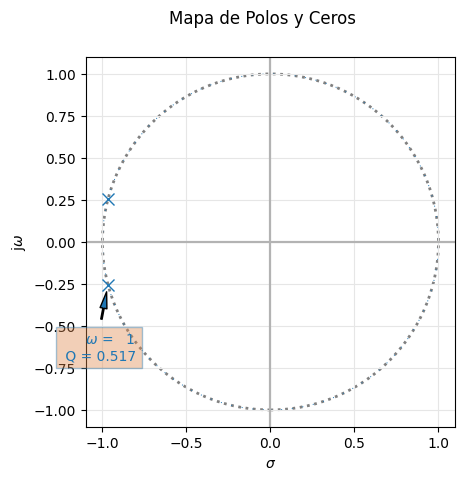

In [40]:
# --- Simulación Sallen Key ---
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from pytc2.sistemas_lineales import analyze_sys, pzmap

Q = 0.517
w0 = 1
K = 3.16

# Valores de los componetes
c1 = (1/Q + np.sqrt(1/Q**2 - 8*(1-K))) / 4
c2 = 4 / (1/Q + np.sqrt(1/Q**2 - 8*(1-K)))
R3 = 1 / (K - 1)

# Transferencia
num_slk = [K/(c1*c2)]
den_slk = [1, 2/c2 + (1 - K)/c1, 1/(c1*c2)]

sys_slk = signal.TransferFunction(num_slk, den_slk)
pzmap(sys_slk, "Sallen-Key Low-Pass")

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

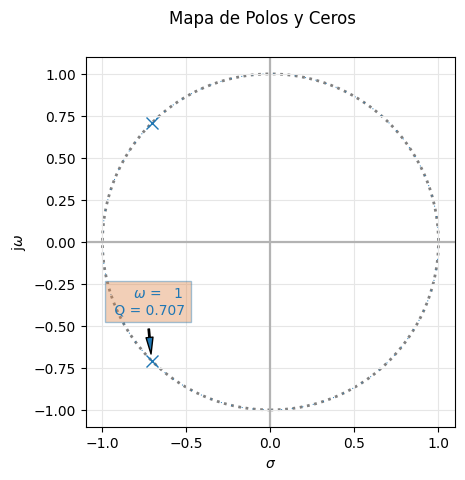

In [ ]:
# --- Simulación KHN ---
Q = 0.707
w0 = 1

# Valores de los componentes
c1 = 3*Q/2
c2 = 2/(3*Q)

# Transferencia
num_khn = [-1/(c1*c2)]
den_khn = [1, 3/(2*c1), 1/(c1*c2)]

sys_khn = signal.TransferFunction(num_khn, den_khn)
pzmap(sys_khn, "KHN Low-Pass")

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

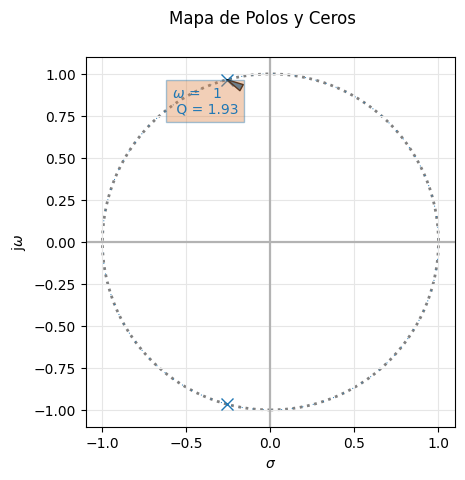

In [42]:
# --- Simulación MFB ---
Q_mfb = 1.932 # Butterworth
c1_mfb = 3 * Q_mfb
c2_mfb = 1 / (3 * Q_mfb)

num_mfb = [-1 / (c1_mfb * c2_mfb)]
den_mfb = [1, 3/c1_mfb, 1/(c1_mfb * c2_mfb)]

sys_mfb = signal.TransferFunction(num_mfb, den_mfb)
pzmap(sys_mfb, "MFB Low-Pass")

### Análisis de la Transferencia Total (Cascada)
Para obtener la respuesta del filtro de **6to orden**, combinamos las tres etapas anteriores en cascada. Matemáticamente, esto equivale a la multiplicación de sus funciones de transferencia individuales:

$$H_{total}(s) = T_1(s) \cdot T_2(s) \cdot T_3(s)$$

A continuación, realizamos la convolución de los numeradores y denominadores para obtener el sistema resultante.

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>]]

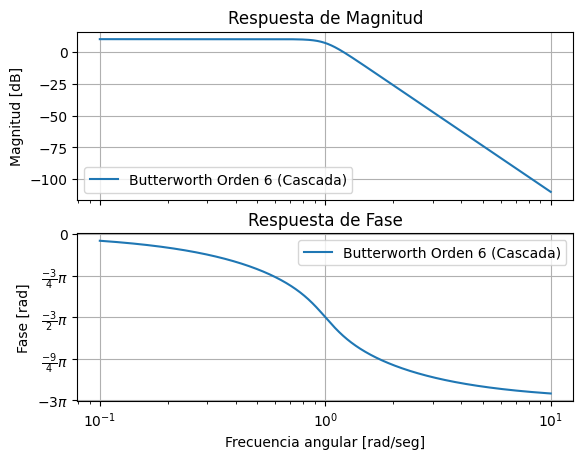

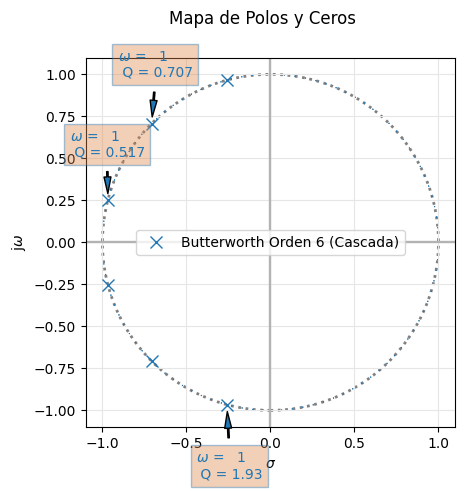

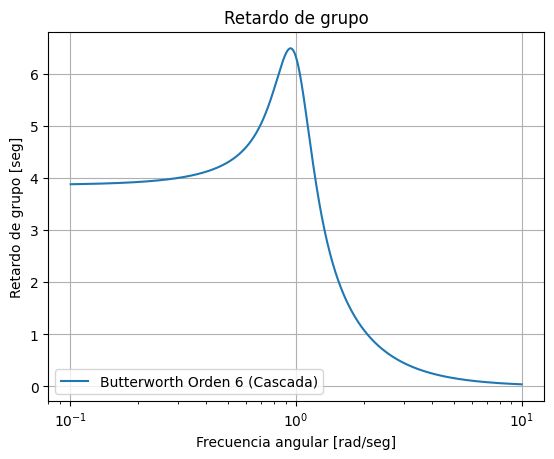

In [43]:
T1 = signal.lti(num_slk, den_slk) # Sallen-Key
T2 = signal.lti(num_khn, den_khn) # KHN
T3 = signal.lti(num_mfb, den_mfb) # MFB

# Combinamos en cascada (Multiplicación de polinomios)
num_total = np.polymul(num_slk, np.polymul(num_khn, num_mfb))
den_total = np.polymul(den_slk, np.polymul(den_khn, den_mfb))

sys_total = signal.TransferFunction(num_total, den_total)
analyze_sys(sys_total, "Butterworth Orden 6 (Cascada)")

### Simulación Circuital en LTspice

<img src="./img/ltspice_01.png" width="1000">  


Para validar la función de transferencia obtenida, se simuló la red normalizada en LTspice utilizando los siguientes parámetros:

* **Configuración de Simulación:** `.ac dec 100 0.01 100`.
* **Modelo de OPAMP:** UniversalOpamp2.

### Resultados Obtenidos
La simulación confirma el comportamiento de un filtro Butterworth de orden 6:
1. El módulo se mantiene constante en $10\ dB$ hasta $\omega<1$.
2. En $\omega = 1$ el módulo es exactamente $7 \ dB$
3. La fase presenta un desplazamiento que inicia en $0°$ y termina en $-540°$, pasando por $-270°$ en la frecuencia de corte normalizada ($f_c = \frac{1}{2\pi} \approx 159\  mHz$).  

<img src="./img/ltspice_02.png" width="1500">  

---